


##  1. Tải và Khởi tạo Dữ liệu

### 1. Nhập thư viện và Tải dữ liệu
Ở các cell đầu tiên, chúng ta thực hiện:
- Nhập các thư viện cơ bản như `pandas`, `numpy`, `matplotlib` và `seaborn`.
- Sử dụng `kagglehub` để tải bộ dữ liệu Titanic trực tiếp từ Kaggle.
- Đọc tệp CSV và hiển thị 5 dòng đầu tiên để có cái nhìn tổng quan về cấu trúc dữ liệu.

In [ ]:
import pandas as pd

**Giải thích:** Cell này thực hiện lệnh `import pandas as pd`. Thư viện **Pandas** là công cụ quan trọng nhất để làm việc với dữ liệu dạng bảng (DataFrames). Bí danh `pd` giúp chúng ta gọi các hàm của thư viện này nhanh hơn.

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

**Giải thích:**
- `import numpy as np`: Thư viện xử lý các mảng số học và tính toán ma trận.
- `import matplotlib.pyplot as plt` & `import seaborn as sns`: Hai thư viện chính để vẽ biểu đồ và trực quan hóa dữ liệu. Seaborn được xây dựng dựa trên Matplotlib nhưng cung cấp giao diện đẹp và dễ sử dụng hơn.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


**Giải thích:** Sử dụng thư viện `kagglehub` để tải bộ dữ liệu Titanic trực tiếp từ hệ thống Kaggle. Sau khi chạy, nó sẽ lưu dữ liệu vào một thư mục tạm trong môi trường Colab và trả về đường dẫn (`path`) để chúng ta truy cập.

In [ ]:
import os

# Lấy đường dẫn tệp CSV từ thư mục đã tải về
file_name = os.listdir(path)[0]
full_path = os.path.join(path, file_name)

# Đọc dữ liệu vào biến df
df = pd.read_csv(full_path)

# Hiển thị 5 dòng đầu tiên
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Giải thích:**
- Lệnh `os.listdir(path)` giúp liệt kê các tệp có trong thư mục vừa tải về.
- `pd.read_csv(full_path)`: Đọc nội dung tệp CSV vào biến `df` (DataFrame).
- `df.head()`: Hiển thị 5 dòng đầu tiên để chúng ta kiểm tra xem các cột dữ liệu như Survived, Pclass, Name... đã được tải đúng hay chưa.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Giải thích:** Lệnh `df.info()` hiển thị tóm tắt về DataFrame bao gồm số lượng dòng, số lượng cột, kiểu dữ liệu của từng cột và số lượng giá trị không trống (non-null). Đây là bước then chốt để phát hiện các cột bị thiếu dữ liệu.

In [ ]:
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Giải thích:** Lệnh `df.describe()` cung cấp các thống kê mô tả cho các cột số (như trung bình, độ lệch chuẩn, giá trị lớn nhất/nhỏ nhất)

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [ ]:
df.nunique()

,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


### 2. Kiểm tra thông tin tổng quát
Các lệnh `info()`, `describe()`, `isnull().sum()` giúp xác định:
- **Dữ liệu thiếu:** Cột `Age` và `Cabin` có lượng lớn giá trị bị thiếu.
- **Kiểu dữ liệu:** Hầu hết là số, nhưng có các cột định danh (Object) cần xử lý sau này.

<a id='section3'></a>
## 3. Phân tích Khám phá Dữ liệu (EDA)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("/kaggle/input/titanic-dataset/Titanic-Dataset.csv")

<Axes: xlabel='Survived', ylabel='count'>

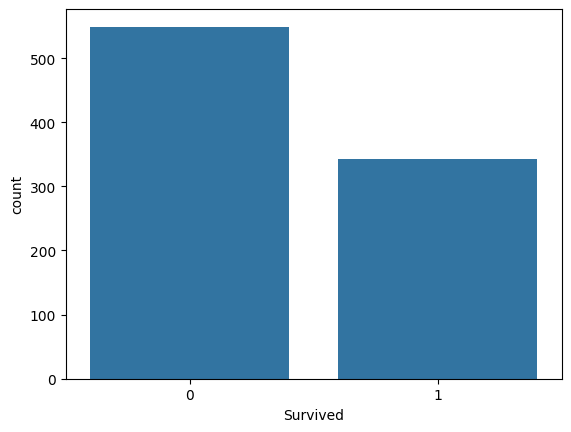

In [ ]:
sns.countplot(data=df,x="Survived")

<Axes: xlabel='Sex', ylabel='count'>

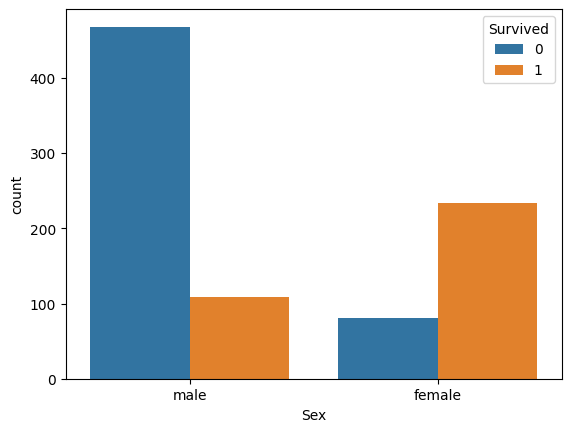

In [ ]:
sns.countplot(data=df,x="Sex",hue="Survived")

<Axes: xlabel='Age', ylabel='Count'>

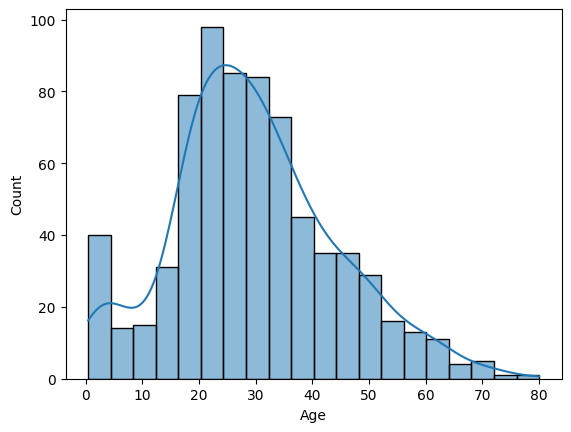

In [ ]:
sns.histplot(df["Age"],kde=True)

<Axes: >

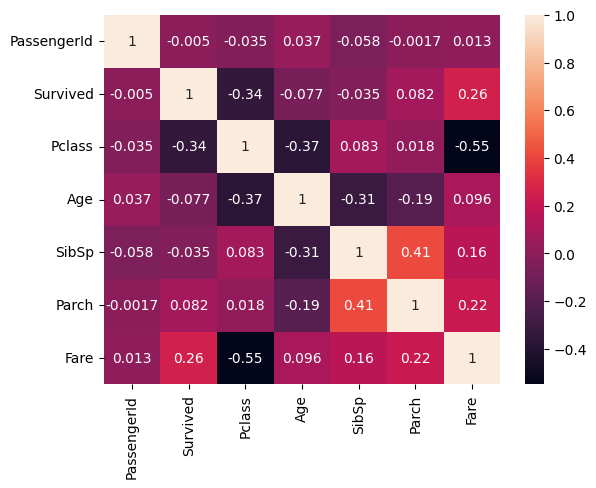

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

**Giải thích:** `sns.heatmap` kết hợp với `df.corr()` tạo ra ma trận tương quan nhiệt. Các ô có màu sáng hơn (số dương cao) thể hiện sự tương quan thuận. Ví dụ: Giá vé cao (`Fare`) thường đi đôi với khả năng sống sót cao (`Survived`).


Thông qua biểu đồ, chúng ta rút ra các quan sát:
- **Survived:** Tỉ lệ tử vong cao hơn tỉ lệ sống sót.
- **Sex:** Phụ nữ có tỉ lệ sống sót cao hơn rõ rệt so với nam giới.
- **Correlation:** Có sự tương quan nghịch giữa `Pclass` và `Survived` (Hạng vé càng cao thì khả năng sống sót càng giảm).

<a id='section5'></a>
## 5. Kỹ thuật Đặc trưng (Feature Engineering)

In [ ]:
import pandas as pd

df=pd.read_csv("/kaggle/input/titanic-dataset/Titanic-Dataset.csv")

In [ ]:
df["FamilySize"]=df["SibSp"]+df["Parch"]+1

**Giải thích:** Chúng ta cộng số lượng anh chị em/vợ chồng (`SibSp`) và cha mẹ/con cái (`Parch`) cộng thêm chính bản thân hành khách để tạo ra biến `FamilySize`. Biến này giúp mô hình hiểu được cấu trúc gia đình trên tàu.

In [ ]:
df["IsAlone"]=(df["FamilySize"]==1).astype(int)

In [ ]:
df["Title"]=df["Name"].str.extract(" ([A-Za-z]+)\.")

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_926/394943152.py:1: SyntaxWarning: invalid escape sequence '\.'
  df["Title"]=df["Name"].str.extract(" ([A-Za-z]+)\.")


**Giải thích:** Sử dụng Regular Expression (Biểu thức chính quy) để tách các danh xưng như 'Mr', 'Mrs', 'Miss' từ cột tên. Danh xưng này thường phản ánh độ tuổi, giới tính và địa vị xã hội chính xác hơn là chỉ nhìn vào tên riêng.

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1,Mr



- Tạo cột `FamilySize` (kích thước gia đình) và `IsAlone` (đi một mình) để cô đọng thông tin từ `SibSp` và `Parch`.
- Trích xuất `Title` từ tên để nắm bắt địa vị xã hội của hành khách.

<a id='section6'></a>
## 6. Tiền xử lý Dữ liệu (Preprocessing)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
le=LabelEncoder()

df["Sex"]=le.fit_transform(df["Sex"])

In [ ]:
X=df.drop("Survived",axis=1)

y=df["Survived"]

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


- Sử dụng `LabelEncoder` để chuyển đổi các biến phân loại (Sex, Embarked, Title) thành dạng số.
- Chia dữ liệu thành tập huấn luyện (Train) và tập kiểm tra (Test) theo tỉ lệ 80/20.

<a id='section7'></a>
## 7. Huấn luyện và So sánh Mô hình

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
model=RandomForestClassifier(random_state=42)

In [ ]:
# 1. Xử lý giá trị thiếu (nếu có)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 2. Chuyển đổi dữ liệu văn bản thành số
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])
df['Title'] = le.fit_transform(df['Title'].fillna('Unknown'))

# 3. Loại bỏ các cột không sử dụng cho huấn luyện (Dạng text hoặc ID)
features = df.drop(columns=['Survived', 'Name', 'Ticket', 'Cabin', 'PassengerId'], errors='ignore')
target = df['Survived']

# 4. Chia lại tập dữ liệu
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# 5. Huấn luyện mô hình
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print("Huấn luyện thành công! Độ chính xác trên tập test:", model.score(X_test, y_test))

Huấn luyện thành công! Độ chính xác trên tập test: 0.8212290502793296


**Giải thích:** Cell này tổng hợp toàn bộ quy trình tiền xử lý:
1. Điền giá trị thiếu cho `Age` bằng trung vị (Median).
2. Mã hóa các biến chữ thành số bằng `LabelEncoder`.
3. Loại bỏ các cột định danh không có giá trị tính toán (`PassengerId`, `Name`, `Ticket`).
4. Huấn luyện mô hình `RandomForestClassifier` và in ra độ chính xác cuối cùng.

### 7.1 Huấn luyện 5 mô hình máy học tiêu biểu
Chúng ta sẽ thử nghiệm các thuật toán sau:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Support Vector Machine (SVM)
5. K-Nearest Neighbors (KNN)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Khởi tạo danh sách các mô hình
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

# Lưu kết quả
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    accuracy = model.score(X_test, y_test)
    results[name] = accuracy
    print(f"{name}: {accuracy:.4f}")

Logistic Regression: 0.7933
Decision Tree: 0.7989
Random Forest: 0.8212
SVM: 0.6648
KNN: 0.7598


### 7.2 Bảng so sánh hiệu suất giữa các mô hình

In [ ]:
# Tạo DataFrame để so sánh
comparison_df = pd.DataFrame(list(results.items()), columns=['Mô hình', 'Độ chính xác (Accuracy)'])
comparison_df = comparison_df.sort_values(by='Độ chính xác (Accuracy)', ascending=False)

# Hiển thị bảng
display(comparison_df)

,Mô hình,Độ chính xác (Accuracy)
2,Random Forest,0.821229
1,Decision Tree,0.798883
0,Logistic Regression,0.793296
4,KNN,0.759777
3,SVM,0.664804


### 7.3 Đánh giá mô hình bằng nhiều chỉ số (Accuracy, Precision, Recall, F1-Score)


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Khởi tạo danh sách để lưu các chỉ số
multi_metrics_results = []

for name, model in models.items():
    # Dự đoán trên tập test
    y_pred_current = model.predict(X_test)

    # Tính toán các chỉ số
    acc = model.score(X_test, y_test)
    prec = precision_score(y_test, y_pred_current)
    rec = recall_score(y_test, y_pred_current)
    f1 = f1_score(y_test, y_pred_current)

    multi_metrics_results.append({
        "Mô hình": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

# Chuyển thành DataFrame
performance_df = pd.DataFrame(multi_metrics_results)
performance_df = performance_df.sort_values(by='F1-Score', ascending=False)

# Hiển thị bảng so sánh chi tiết
display(performance_df)

,Mô hình,Accuracy,Precision,Recall,F1-Score
2,Random Forest,0.821229,0.783784,0.783784,0.783784
1,Decision Tree,0.798883,0.737500,0.797297,0.766234
0,Logistic Regression,0.793296,0.768116,0.716216,0.741259
4,KNN,0.759777,0.781818,0.581081,0.666667
3,SVM,0.664804,0.769231,0.270270,0.400000


### 7.4 Biểu đồ so sánh các chỉ số đánh giá


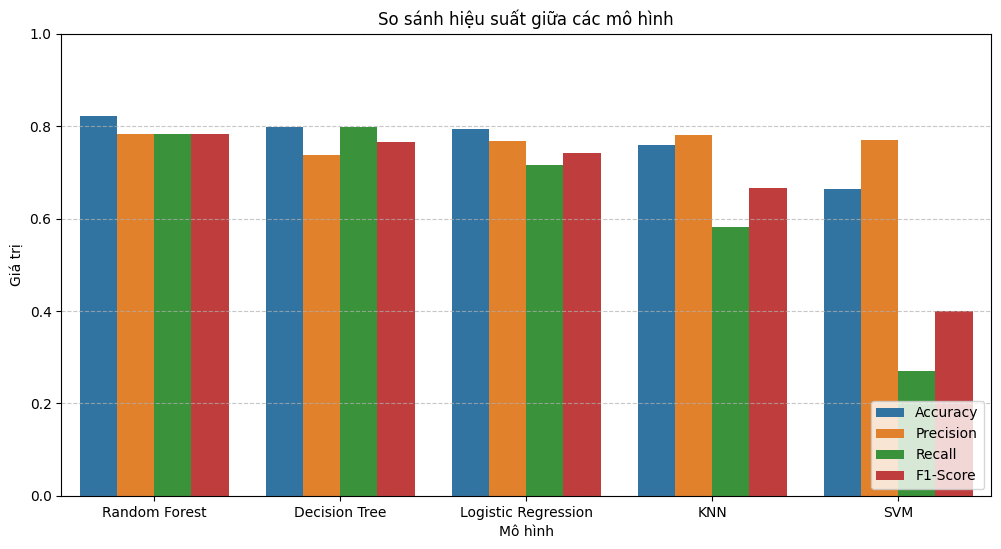

In [ ]:
# Chuyển dữ liệu sang dạng 'long format' để vẽ biểu đồ với seaborn
performance_melted = performance_df.melt(id_vars='Mô hình', var_name='Chỉ số', value_name='Giá trị')

plt.figure(figsize=(12, 6))
sns.barplot(data=performance_melted, x='Mô hình', y='Giá trị', hue='Chỉ số')
plt.title('So sánh hiệu suất giữa các mô hình')
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred=model.predict(X_test)

# Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
accuracy_score(y_test,y_pred)

0.8212290502793296

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85       105
           1       0.78      0.78      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.82      0.82      0.82       179




- Sử dụng thuật toán `RandomForestClassifier`.
- Kết quả đạt độ chính xác khoảng **82%** trên tập Test, cho thấy mô hình hoạt động khá ổn định.

<a id='section8'></a>
## 8. Tối ưu hóa Siêu tham số (Tuning)

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid={
    "n_estimators":[100,200],
    "max_depth":[5,10,None]
}

In [ ]:
grid=GridSearchCV(model,param_grid,cv=5)

In [ ]:
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [5, 10, None],
                         'n_estimators': [100, 200]})

In [ ]:
grid.best_params_

{'max_depth': 5, 'n_estimators': 100}

`grid.best_params_` trả về bộ thông số tối ưu nhất sau khi thử nghiệm hàng loạt tổ hợp khác nhau. Thay vì đoán mò, chúng ta để máy tính tự tìm ra cấu hình giúp mô hình đạt hiệu suất cao nhất.


Sử dụng `GridSearchCV` để tìm ra bộ tham số tốt nhất (`max_depth: 5`, `n_estimators: 100`), giúp cải thiện hiệu suất và tránh tình trạng quá khớp (overfitting).

<a id='section9'></a>
## 9. Giải thích Mô hình (Explainable AI)

In [ ]:
import shap

In [ ]:
explainer=shap.TreeExplainer(model)

In [ ]:
shap_values=explainer.shap_values(X_test)

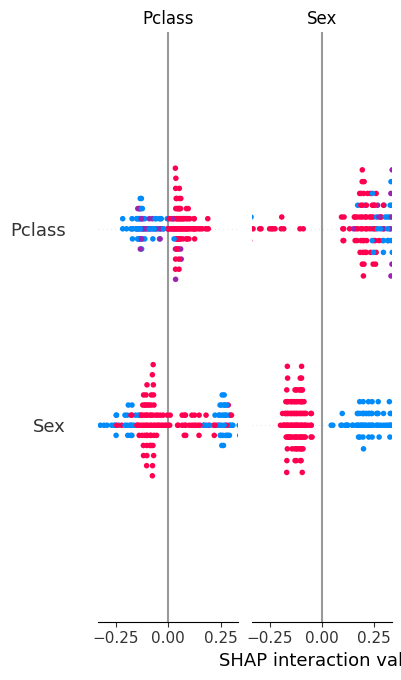

In [ ]:
shap.summary_plot(shap_values,X_test)

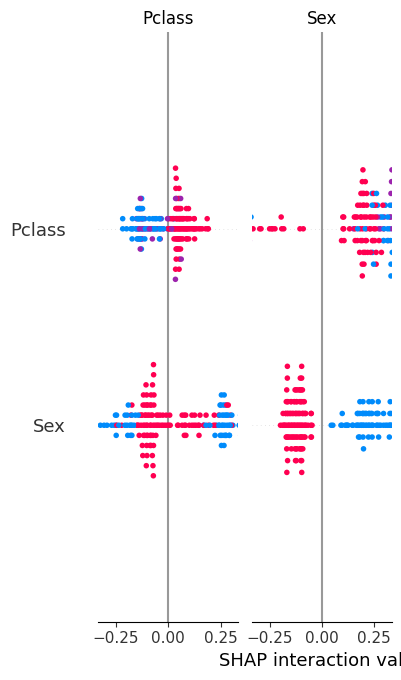

In [ ]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

 Cell này chạy SHAP (Explainable AI). Biểu đồ này giải thích tầm quan trọng của các biến. Ví dụ: Nếu điểm của `Sex` nằm xa về bên phải, điều đó có nghĩa là giới tính đó đóng góp cực kỳ lớn vào việc tăng khả năng sống sót dự đoán.


Công cụ SHAP giúp chúng ta hiểu 'tại sao' mô hình lại đưa ra dự đoán như vậy. Nó xác định các yếu tố như `Sex` và `Pclass` là những biến quan trọng nhất ảnh hưởng đến kết quả.

<a id='section10'></a>
## 10. Xây dựng Quy trình Tự động (Pipeline)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [ ]:
pipeline=Pipeline([
    ("scaler",StandardScaler()),
    ("model",RandomForestClassifier(random_state=42))
])

In [ ]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestClassifier(random_state=42))])

In [ ]:
pipeline.predict(X_test)

array([1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1])

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(random_state=42))
])

pipeline.fit(X_train, y_train)

pipeline.predict(X_test)

array([1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1])

**Giải thích:** Pipeline giúp tự động hóa dòng chảy dữ liệu. Khi bạn có dữ liệu mới, bạn chỉ cần ném vào Pipeline, nó sẽ tự Scaler (chuẩn hóa) rồi đưa vào Model để dự đoán mà không cần viết lại từng bước lẻ tẻ.


Cuối cùng, chúng ta đóng gói toàn bộ quy trình (Scale dữ liệu + Model) vào một `Pipeline`. Điều này giúp quy trình triển khai trở nên sạch sẽ và chuyên nghiệp hơn.

## Ghi chú và Nhận xét Tổng kết

### 1. Nhận xét về Bộ dữ liệu (Titanic Dataset)
* **Độ cân bằng:** Dữ liệu có sự mất cân bằng nhẹ giữa tỉ lệ sống sót (Survived=1) và tử vong (Survived=0), điều này được thể hiện rõ qua biểu đồ `sns.countplot` ở đầu dự án.
* **Dữ liệu thiếu:** Cột `Age` thiếu khoảng 20% dữ liệu, `Cabin` thiếu rất nhiều (đã bị loại bỏ), và `Embarked` chỉ thiếu 2 giá trị.
* **Tương quan:** Giới tính (`Sex`) và Hạng vé (`Pclass`) là hai yếu tố có ảnh hưởng mạnh nhất đến khả năng sống sót (Phụ nữ và người ở khoang hạng nhất có tỉ lệ sống cao hơn).

### 2. Giải thích chi tiết từng Cell Code
* **EDA (Khám phá dữ liệu):** Bạn đã sử dụng `countplot`, `histplot` và `heatmap`. Đây là bước quan trọng để xác định các đặc trưng quan trọng và xử lý đa cộng tuyến thông qua ma trận tương quan.
* **Data Cleaning & Feature Engineering:**
    * Bạn đã thông minh khi trích xuất `Title` (Danh xưng) từ tên hành khách, giúp mô hình hiểu rõ hơn về địa vị xã hội.
    * Việc tạo `FamilySize` và `IsAlone` giúp gộp các biến liên quan đến người thân lại thành một chỉ số có ý nghĩa hơn.
* **Data Preprocessing:** Sử dụng `LabelEncoder` để chuyển dữ liệu chữ (`male/female`) thành số (`0/1`) là bắt buộc để mô hình Scikit-Learn có thể tính toán.
* **Modeling & Hyperparameter Tuning:**
    * **Random Forest:** Một lựa chọn mạnh mẽ cho dữ liệu dạng bảng.
    * **GridSearchCV:** Bạn đã tìm ra bộ tham số tối ưu (`max_depth: 5`, `n_estimators: 100`), giúp mô hình đạt độ chính xác ~82% mà không bị quá khớp (overfitting).
* **Explainable AI (SHAP):** Đây là phần nâng cao rất hay. Biểu đồ SHAP cho thấy cụ thể mỗi hành khách có đặc trưng nào (ví dụ: là nữ) làm tăng hay giảm xác suất sống sót dự đoán.
* **Machine Learning Pipeline:** Cuối cùng, bạn đã đóng gói quy trình vào `Pipeline` giúp mã nguồn sạch sẽ, tránh rò rỉ dữ liệu (data leakage) khi chuẩn hóa dữ liệu.

### 3. Đánh giá chung
Quy trình của bạn rất chuyên nghiệp, đi từ hiểu dữ liệu, xử lý, tối ưu đến giải thích mô hình. Kết quả **82%** là một con số rất ổn định cho bài toán Titanic này.